In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

HERE = Path.cwd().resolve()
ANALYSIS_ROOT = next((p for p in (HERE, *HERE.parents) if (p / 'seacofs_tilt_tools.py').exists()), None)
if ANALYSIS_ROOT is None:
    raise FileNotFoundError('Run from seacofs_eddy_tilt_analysis or one of its subfolders.')
CASE_ROOT = ANALYSIS_ROOT / 'case_studies'
for path in (ANALYSIS_ROOT, CASE_ROOT):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import seacofs_tilt_tools as tilt
from case_study_tools import PVAlignmentConfig, add_pv_alignment_diagnostics

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 60)

In [2]:
DOMINANCE_FACTOR = 2.0
MIN_DEPTH_m = 3000.0
MIN_TILT_km = 0.0

paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
df_eddies, _ = tilt.load_tilt_tables(paths)
df_eddies = tilt.add_region_labels(df_eddies, grid)
df_eddies = tilt.add_pv_gradient_terms(df_eddies, grid, core_mean=True)

config = PVAlignmentConfig(
    dominance_factor=DOMINANCE_FACTOR,
    min_open_ocean_depth_m=MIN_DEPTH_m,
    min_tilt_distance_km=MIN_TILT_km,
)
d = add_pv_alignment_diagnostics(df_eddies, config)
assert d.beta.dropna().median() > 0, 'Expected positive planetary beta after gradient sign correction.'
planetary = d[d.open_ocean_planetary & d.direction_valid].copy()

# Compass bearing: 0° = north and 90° = east.
planetary['tilt_x_km'] = planetary.TiltDis * np.sin(np.deg2rad(planetary.TiltDir))
planetary['tilt_y_km'] = planetary.TiltDis * np.cos(np.deg2rad(planetary.TiltDir))

In [3]:
full = df_eddies.groupby('Eddy').size()
kept = planetary.groupby('Eddy').size()

complete_eddies = full.index[(full - kept.reindex(full.index, fill_value=0)).eq(6)]
complete_eddies

Index([207, 229, 519, 1172, 1946, 2589, 2710, 2765, 2978], dtype='int64', name='Eddy')

(np.float64(0.0),
 np.float64(988.1356688684336),
 np.float64(0.0),
 np.float64(1561.702894718129))

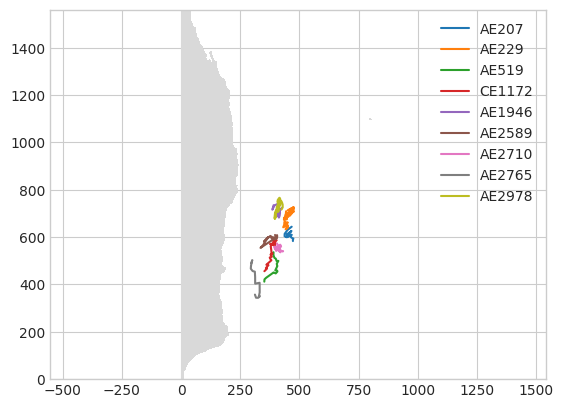

In [4]:
df_complete = planetary[planetary.Eddy.isin(complete_eddies)].copy()

plt.contourf(grid.X_grid, grid.Y_grid, np.where(grid.mask_rho, np.nan,0))
for eddy in df_complete.Eddy.unique():
    df = df_complete[df_complete.Eddy==eddy].copy()
    plt.plot(df.xc, df.yc, label=f'{df.iloc[0].Cyc}{eddy}')
plt.legend()
plt.axis('equal')

(array([ 3.,  8., 12.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  3., 13.,
         8., 17., 14., 17., 27., 25., 23., 15., 14.,  8.,  4.,  1.,  1.,
         2.,  1.,  2.,  1.]),
 array([-2.69274321e-05, -2.37987094e-05, -2.06699867e-05, -1.75412640e-05,
        -1.44125413e-05, -1.12838186e-05, -8.15509595e-06, -5.02637326e-06,
        -1.89765058e-06,  1.23107211e-06,  4.35979479e-06,  7.48851748e-06,
         1.06172402e-05,  1.37459628e-05,  1.68746855e-05,  2.00034082e-05,
         2.31321309e-05,  2.62608536e-05,  2.93895763e-05,  3.25182990e-05,
         3.56470216e-05,  3.87757443e-05,  4.19044670e-05,  4.50331897e-05,
         4.81619124e-05,  5.12906351e-05,  5.44193577e-05,  5.75480804e-05,
         6.06768031e-05,  6.38055258e-05,  6.69342485e-05]),
 <BarContainer object of 30 artists>)

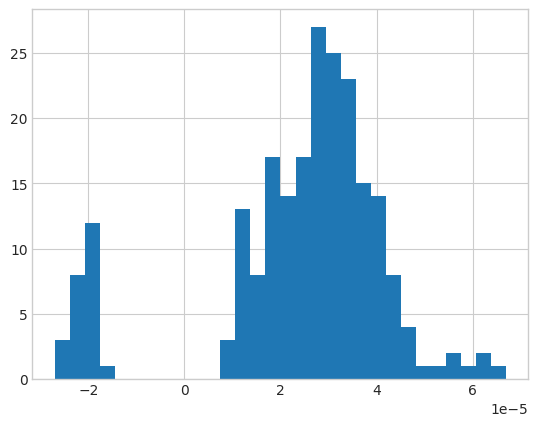

In [5]:
plt.hist(df_complete.w, bins=30)

(array([19., 43., 27., 20., 29., 24., 12.,  8.,  4., 16.,  5.,  1.,  1.,
         2.,  0.,  1.,  0.,  1.,  0.,  1.,  1.,  0.,  0.,  1.,  0.,  0.,
         1.,  1.,  0.,  2.]),
 array([  1.82293823,   5.73355861,   9.64417898,  13.55479935,
         17.46541973,  21.3760401 ,  25.28666047,  29.19728085,
         33.10790122,  37.01852159,  40.92914197,  44.83976234,
         48.75038271,  52.66100309,  56.57162346,  60.48224383,
         64.39286421,  68.30348458,  72.21410495,  76.12472533,
         80.0353457 ,  83.94596607,  87.85658645,  91.76720682,
         95.67782719,  99.58844757, 103.49906794, 107.40968831,
        111.32030869, 115.23092906, 119.14154943]),
 <BarContainer object of 30 artists>)

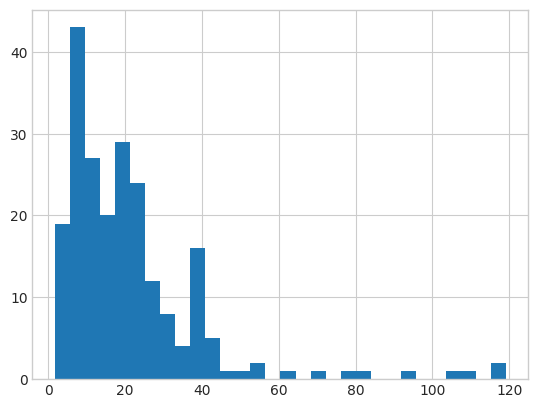

In [6]:
plt.hist(df_complete.TiltDis, bins=30)

(array([10.,  6.,  4.,  6., 22., 14., 13., 14., 13., 15., 14., 15., 15.,
        11., 10., 12.,  7.,  6.,  2.,  2.,  2.,  0.,  1.,  0.,  2.,  1.,
         0.,  1.,  1.,  1.]),
 array([0.12283211, 0.14544758, 0.16806305, 0.19067852, 0.21329399,
        0.23590946, 0.25852494, 0.28114041, 0.30375588, 0.32637135,
        0.34898682, 0.37160229, 0.39421776, 0.41683324, 0.43944871,
        0.46206418, 0.48467965, 0.50729512, 0.52991059, 0.55252606,
        0.57514154, 0.59775701, 0.62037248, 0.64298795, 0.66560342,
        0.68821889, 0.71083437, 0.73344984, 0.75606531, 0.77868078,
        0.80129625]),
 <BarContainer object of 30 artists>)

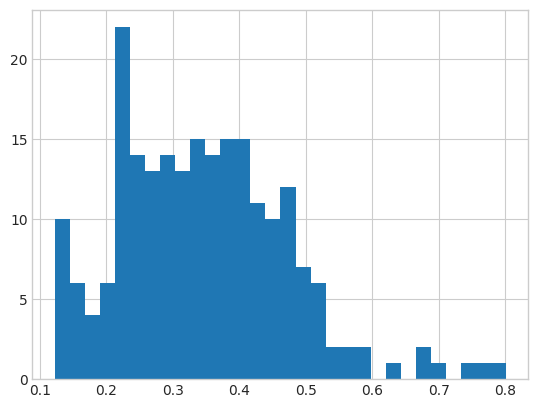

In [7]:
plt.hist(df_complete.Ro, bins=30)

(array([ 1.,  0.,  0.,  1.,  0.,  0.,  0.,  1.,  2.,  2.,  1.,  1.,  5.,
         4.,  5.,  5.,  3., 17., 18., 27., 18., 27., 20., 11., 22., 15.,
         3.,  7.,  2.,  2.]),
 array([-4.31591804, -4.18515024, -4.05438244, -3.92361463, -3.79284683,
        -3.66207902, -3.53131122, -3.40054341, -3.26977561, -3.13900781,
        -3.00824   , -2.8774722 , -2.74670439, -2.61593659, -2.48516879,
        -2.35440098, -2.22363318, -2.09286537, -1.96209757, -1.83132976,
        -1.70056196, -1.56979416, -1.43902635, -1.30825855, -1.17749074,
        -1.04672294, -0.91595513, -0.78518733, -0.65441953, -0.52365172,
        -0.39288392]),
 <BarContainer object of 30 artists>)

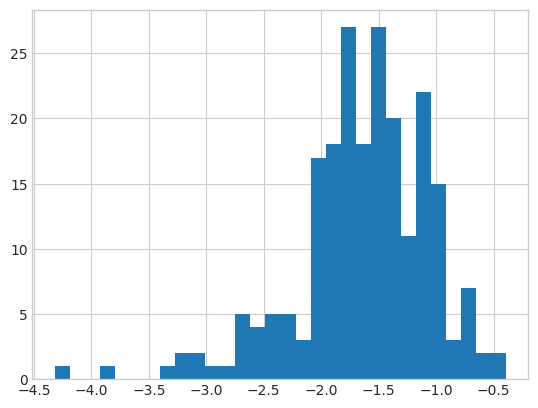

In [8]:
plt.hist(df_complete.topo_plan_ratio, bins=30)

In [21]:
def time_plot(eddy, df_data):
    df = df_data[df_data.Eddy.eq(eddy)].copy()
    t = df.Day - df.Day.iloc[0]

    fig = plt.figure(figsize=(12,10))
    gs = fig.add_gridspec(6, 2, width_ratios=[2,1])
    axs = [fig.add_subplot(gs[i,0]) for i in range(6)]
    axm = fig.add_subplot(gs[:,1])

    axs[0].plot(t, df.TiltDis)
    axs[0].set_ylabel('TiltDis')
    ax0 = axs[0].twinx()
    ax0.plot(t, df.PV_grad_mag, color='tab:red')
    ax0.set_ylabel('PV grad mag', color='tab:red')

    axs[1].plot(t, np.exp(df.topo_plan_ratio))
    axs[1].plot(t, np.exp(df.topo_plan_ratio_smooth))
    axs[1].set_ylabel('Topo/plan')

    axs[2].plot(t, df.Ro)
    axs[2].set_ylabel('Ro')
    ax2 = axs[2].twinx()
    ax2.plot(t, df.w, color='tab:red', label='w')
    # ax2.plot(t, df.f, color='tab:orange', label='f')
    ax2.set_ylabel('w')

    axs[3].plot(t, df.PV)
    axs[3].set_ylabel('PV')
    ax3 = axs[3].twinx()
    ax3.plot(t, df.h, color='tab:red')
    ax3.set_ylabel('h', color='tab:red')

    axs[4].plot(t, df.beta)
    axs[4].set_ylabel('beta')
    ax4 = axs[4].twinx()
    ax4.plot(t, df.lat, color='tab:red')
    ax4.set_ylabel('Latitude', color='tab:red')

    axs[5].scatter(t, df.PV_grad_theta, s=10, label='PV grad')
    axs[5].scatter(t, df.TiltDir, s=10, label='Tilt')
    axs[5].plot(t, df.TiltDir)
    axs[5].scatter(t, df.dtheta_PV_grad, s=10, label=r'$\Delta\theta$')
    axs[5].axhspan(90, 270, color='grey', alpha=.15)
    axs[5].set(xlabel='Eddy age [days]', ylabel='Direction [°]')
    axs[5].legend()

    th = np.deg2rad(df.TiltDir)
    xb = df.xc - df.TiltDis*np.sin(th)
    yb = df.yc - df.TiltDis*np.cos(th)

    cyc = df.iloc[0].Cyc
    clr = 'r' if cyc == 'AE' else 'b'
    axm.plot(df.xc, df.yc, '.-', color=clr, label='Surface')
    axm.scatter(xb, yb, s=10, color=clr, label='Bottom')
    for xs, ys, xbot, ybot in zip(df.xc, df.yc, xb, yb):
        axm.plot([xs, xbot], [ys, ybot], color='g', alpha=.25)

    axm.set(xlabel='x (km)', ylabel='y (km)')
    axm.set_aspect('equal')
    axm.legend()

    fig.suptitle(f'{cyc}{eddy}')
    plt.tight_layout()

In [10]:
df_complete.columns

Index(['Eddy', 'Day', 'Cyc', 'lon', 'lat', 'ic', 'jc', 'xc', 'yc', 'w',
       'Omega', 'q11', 'q12', 'q22', 'Rc', 'psi0', 'AR', 'R', 'Age', 'Date',
       'fname', 'TiltDis', 'TiltDir', 'Region', 'f', 'h', 'dhdx', 'dhdy',
       'beta', 'abs_vort', 'PV', 'PV_grad_plan_x', 'PV_grad_plan_y',
       'PV_grad_topo_x', 'PV_grad_topo_y', 'PV_grad_x', 'PV_grad_y',
       'PV_grad_plan_mag', 'PV_grad_plan_theta', 'PV_grad_topo_mag',
       'PV_grad_topo_theta', 'PV_grad_mag', 'PV_grad_theta', 'dtheta_PV_grad',
       'dtheta_PV_grad_topo', 'dtheta_PV_grad_plan', 'Ro', 'topo_plan_ratio',
       'topo_plan_ratio_smooth', 'planetary_strong', 'open_ocean_planetary',
       'topographic_strong', 'shallow_ocean_topographic',
       'signed_dtheta_PV_grad', 'expected_PV_theta',
       'expected_direction_error', 'direction_valid', 'expected_match',
       'tilt_x_km', 'tilt_y_km'],
      dtype='object')

In [17]:
df_complete

,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,Omega,q11,q12,q22,Rc,psi0,AR,R,Age,Date,fname,TiltDis,TiltDir,Region,f,h,dhdx,dhdy,beta,abs_vort,PV,PV_grad_plan_x,PV_grad_plan_y,PV_grad_topo_x,PV_grad_topo_y,PV_grad_x,PV_grad_y,PV_grad_plan_mag,PV_grad_plan_theta,PV_grad_topo_mag,PV_grad_topo_theta,PV_grad_mag,PV_grad_theta,dtheta_PV_grad,dtheta_PV_grad_topo,dtheta_PV_grad_plan,Ro,topo_plan_ratio,topo_plan_ratio_smooth,planetary_strong,open_ocean_planetary,topographic_strong,shallow_ocean_topographic,signed_dtheta_PV_grad,expected_PV_theta,expected_direction_error,direction_valid,expected_match,tilt_x_km,tilt_y_km
9211,207,2024,AE,154.338684,-34.412508,169,131,467.440410,644.063855,0.000036,0.000014,1.358310,-0.869570,1.307963,99.496585,-67.477127,2.180866,65.075203,28,1995-07-18,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,38.284859,69.871812,D1,-0.000082,4869.382400,-0.000343,0.000618,1.912973e-11,-0.000046,-9.448489e-09,0.0,3.928575e-15,-6.649267e-16,1.199049e-15,-6.649267e-16,5.127624e-15,3.928575e-15,0.0,1.371075e-15,330.989662,5.170557e-15,352.611378,77.260434,98.882150,69.871812,0.441347,-1.052682,-1.052682,True,True,False,False,77.260434,352.611378,77.260434,True,False,35.946614,13.174649
9212,207,2025,AE,154.116913,-34.473645,164,128,450.083097,630.691778,0.000034,0.000013,1.315068,-0.755504,1.247501,95.636849,-60.951947,1.969985,73.971242,28,1995-07-19,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,41.279967,68.999566,D1,-0.000083,4871.018525,-0.000168,0.000503,1.911471e-11,-0.000048,-9.925690e-09,0.0,3.924172e-15,-3.424735e-16,1.025095e-15,-3.424735e-16,4.949267e-15,3.924172e-15,0.0,1.080791e-15,341.526071,4.961102e-15,356.041625,72.957941,87.473494,68.999566,0.413977,-1.289462,-1.289462,True,True,False,False,72.957941,356.041625,72.957941,True,False,38.538057,14.793709
9213,207,2026,AE,153.935261,-34.578758,161,124,437.729431,613.990098,0.000045,0.000019,1.182043,-0.459505,1.139647,78.532035,-59.950339,1.520747,53.802150,28,1995-07-20,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,42.734478,67.840323,D1,-0.000083,4870.770448,-0.000419,0.000438,1.908477e-11,-0.000038,-7.729896e-09,0.0,3.918223e-15,-6.651078e-16,6.948528e-16,-6.651078e-16,4.613076e-15,3.918223e-15,0.0,9.618673e-16,316.252971,4.660777e-15,351.795700,76.044622,111.587352,67.840323,0.545215,-1.404517,-1.404517,True,True,False,False,76.044622,351.795700,76.044622,True,False,39.577950,16.118979
9214,207,2027,AE,153.899318,-34.665355,161,122,437.485307,603.802371,0.000057,0.000023,1.052918,-0.486484,1.372366,72.228867,-60.822138,1.568976,56.123234,28,1995-07-21,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,38.762961,67.120500,D1,-0.000083,4868.891377,-0.000516,0.000511,1.906591e-11,-0.000026,-5.425220e-09,0.0,3.915863e-15,-5.754724e-16,5.689747e-16,-5.754724e-16,4.484838e-15,3.915863e-15,0.0,8.092593e-16,314.674703,4.521608e-15,352.688042,74.432458,112.445797,67.120500,0.681614,-1.576672,-1.404517,True,True,False,False,74.432458,352.688042,74.432458,True,False,35.713269,15.070820
9215,207,2028,AE,153.954201,-34.707229,163,122,443.661633,601.139010,0.000030,0.000012,1.121683,-0.567225,1.384832,81.856426,-62.689162,1.653979,46.836672,28,1995-07-22,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,30.116231,64.939208,D1,-0.000083,4861.661155,-0.000496,0.000473,1.906081e-11,-0.000053,-1.087482e-08,0.0,3.920637e-15,-1.109219e-15,1.057363e-15,-1.109219e-15,4.977999e-15,3.920637e-15,0.0,1.532443e-15,313.628923,5.100083e-15,347.438331,77.500878,111.310285,64.939208,0.363101,-0.939391,-1.081977,True,True,False,False,77.500878,347.438331,77.500878,True,False,27.281055,12.756622
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127292,2978,10637,AE,153.746577,-33.866747,149,138,397.271388,682.498143,0.000031,0.000014,1.521506,0.053440,0.659411,121.849326,-84.438539,1.524469

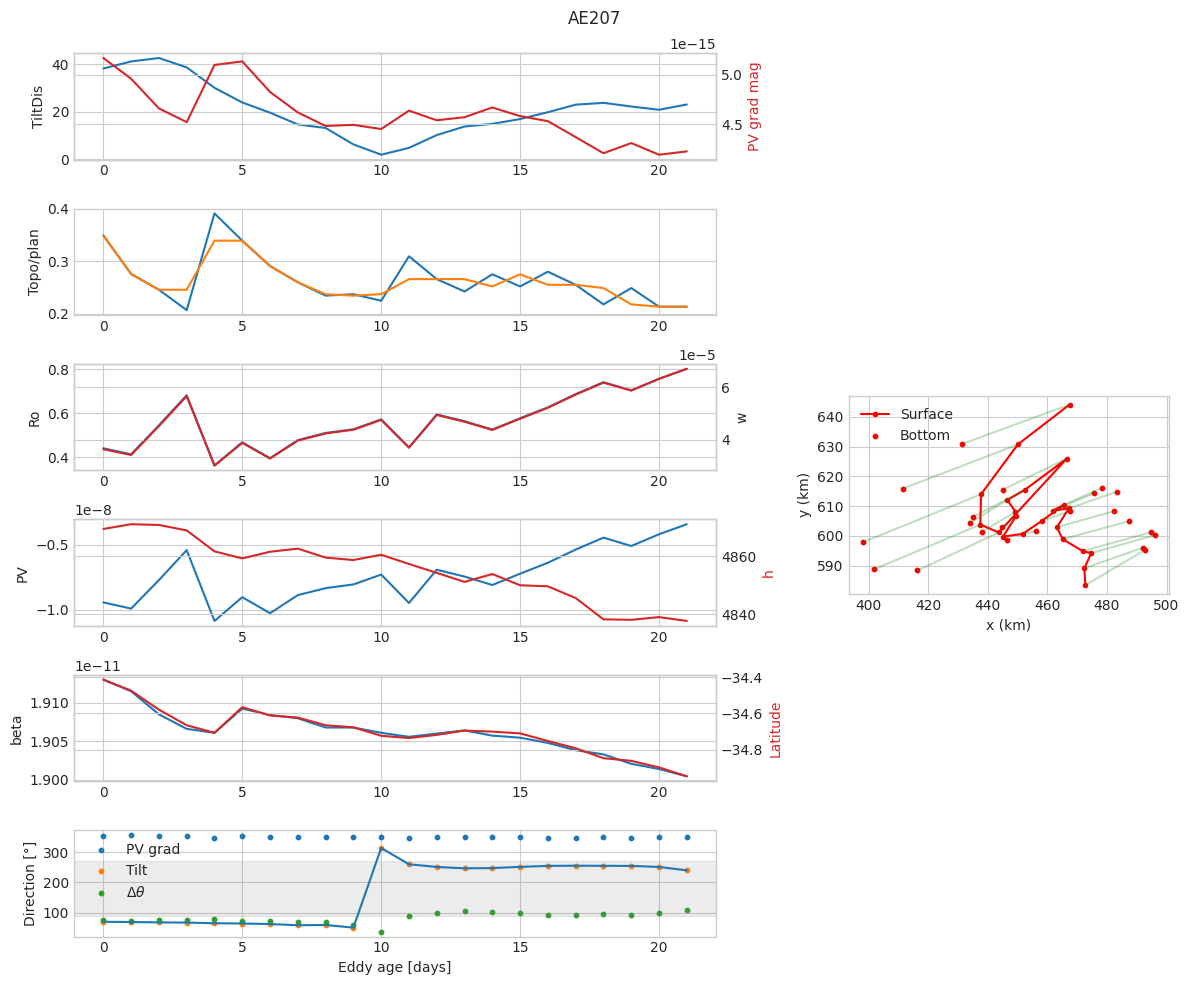

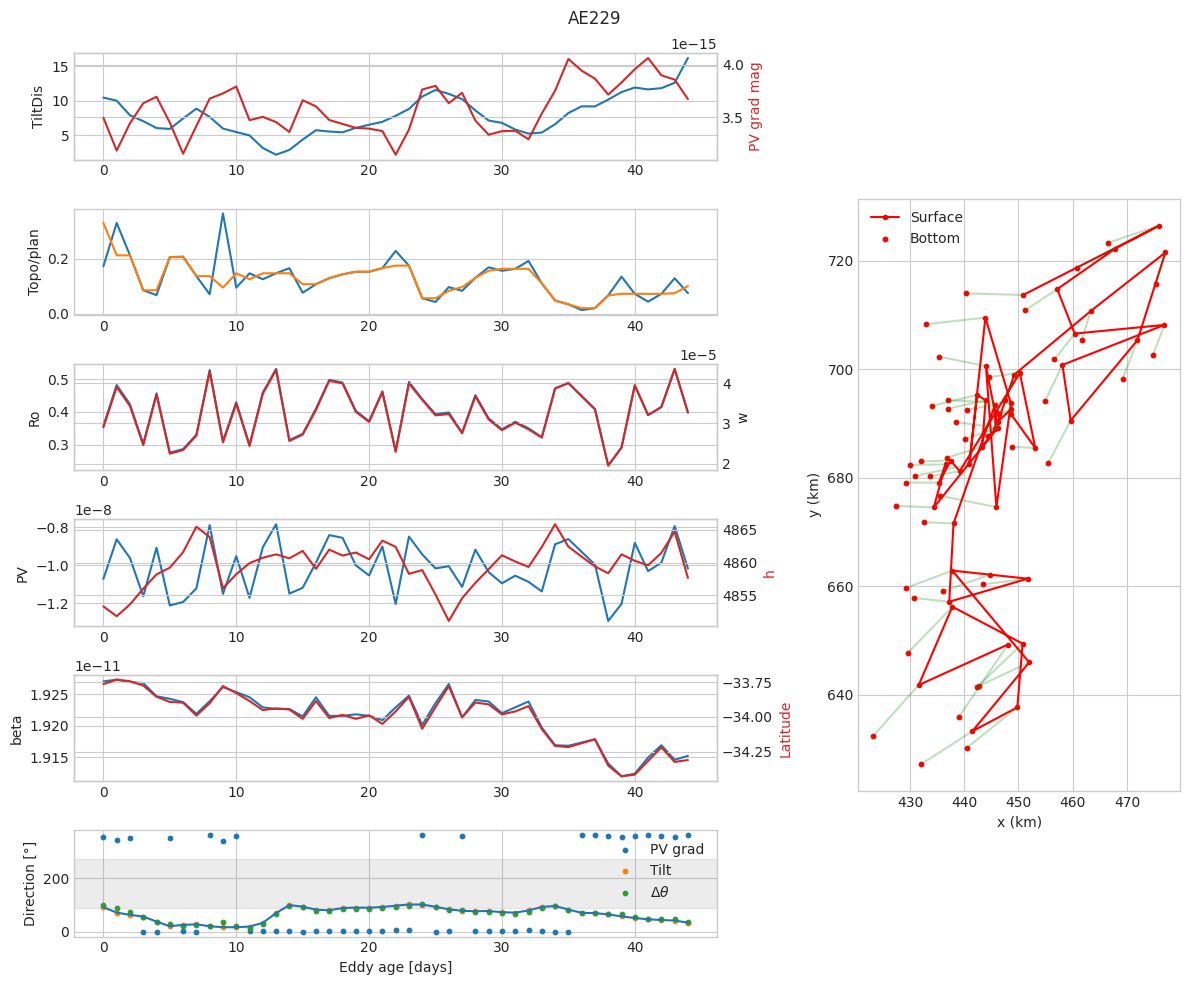

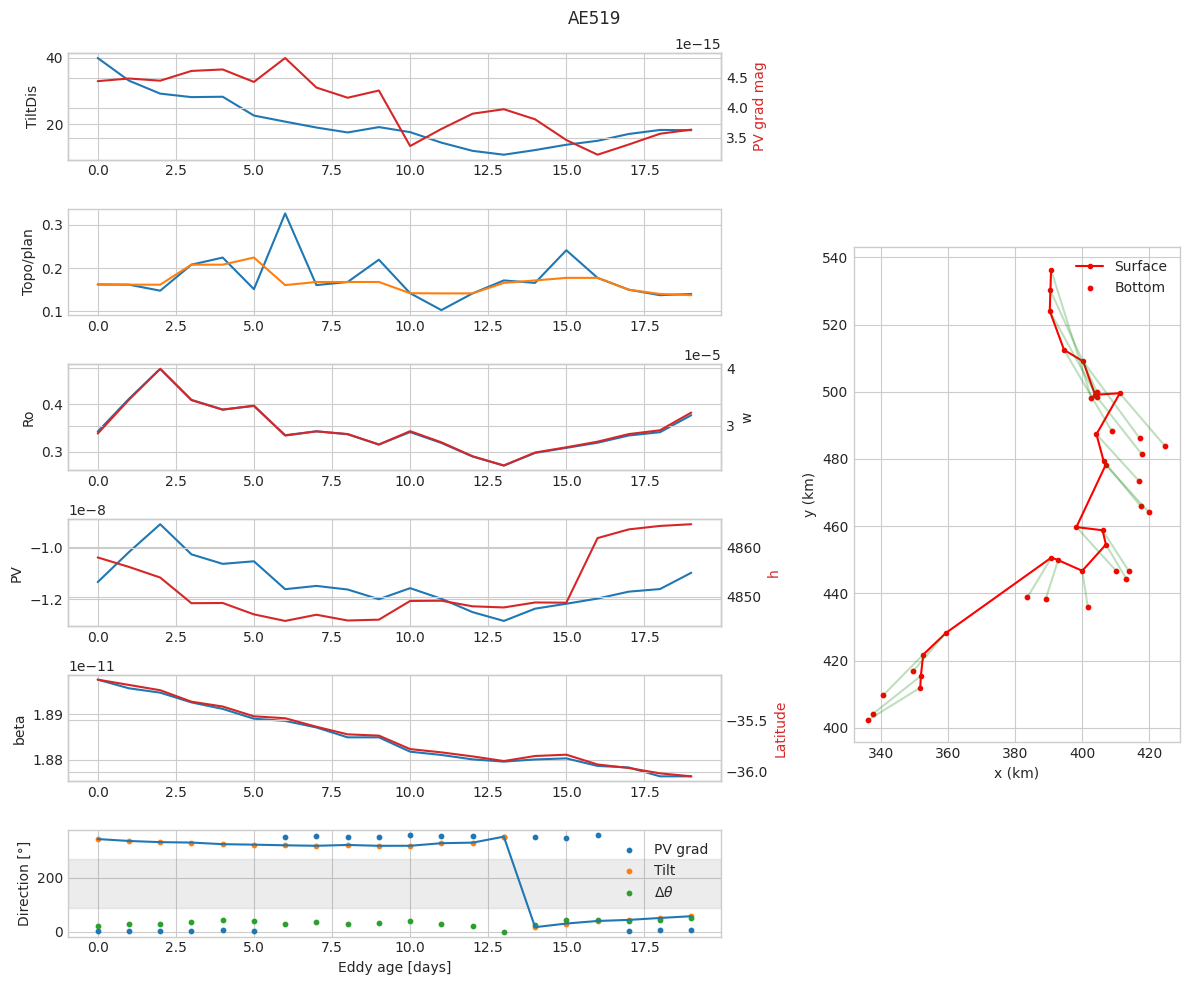

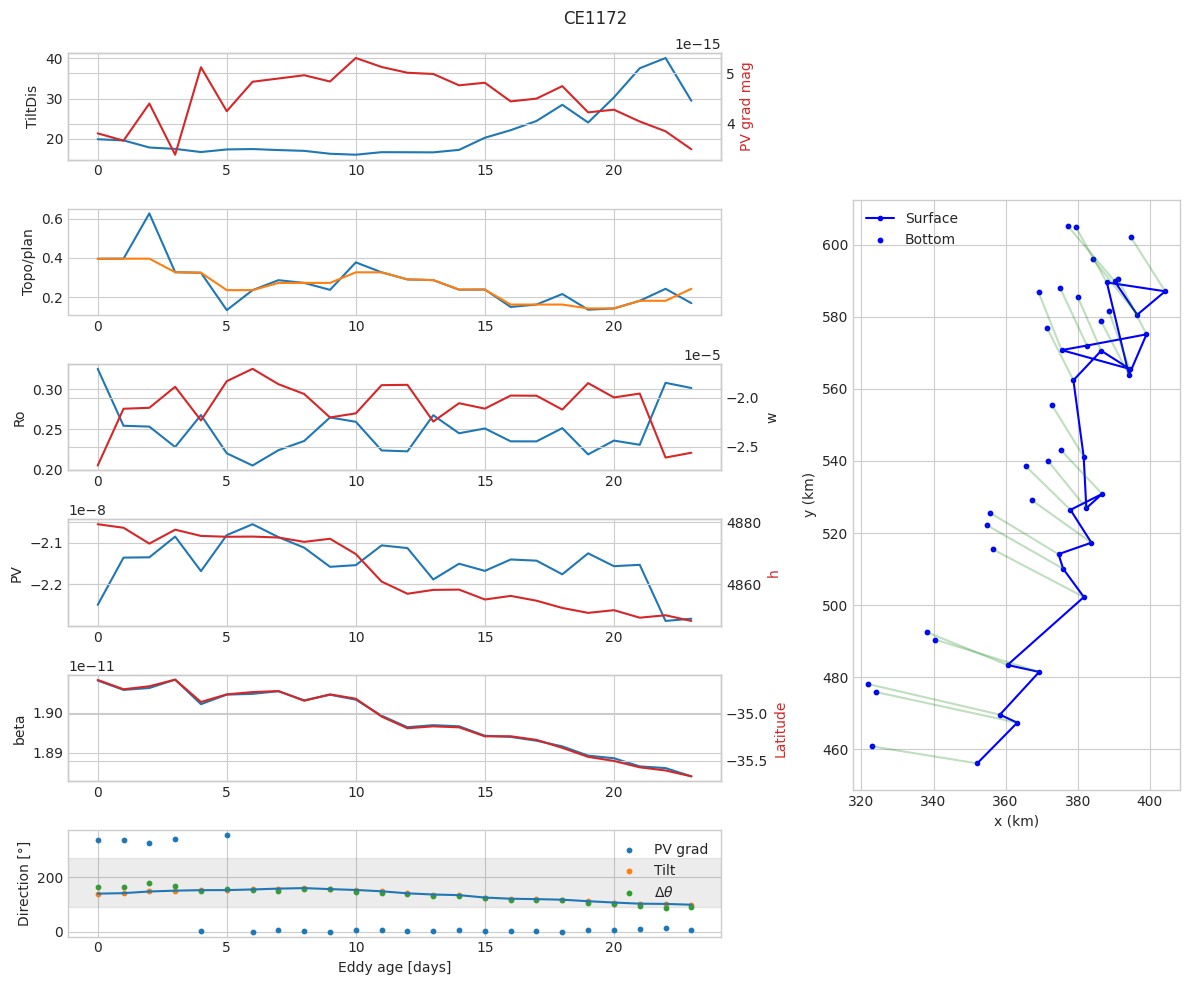

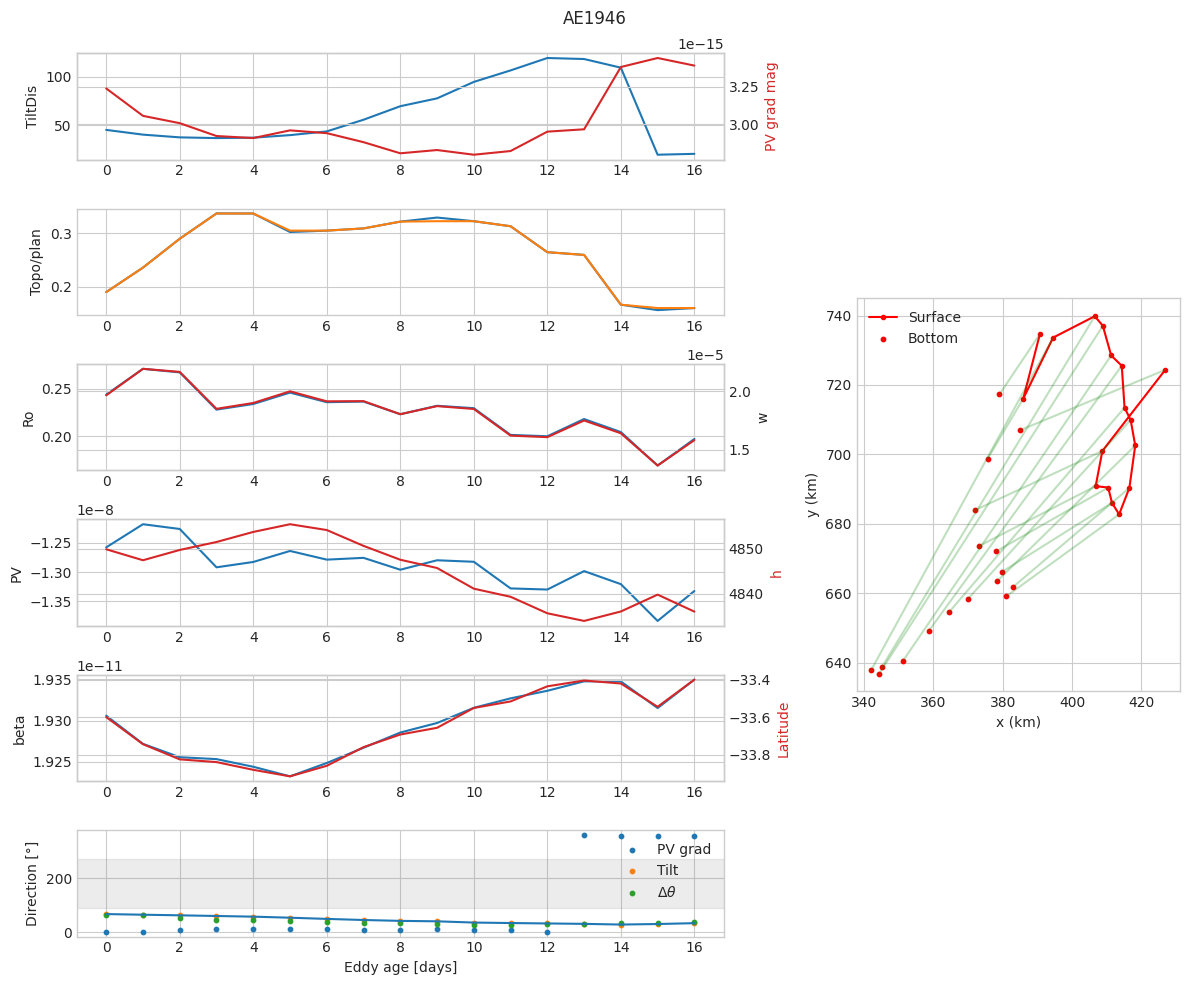

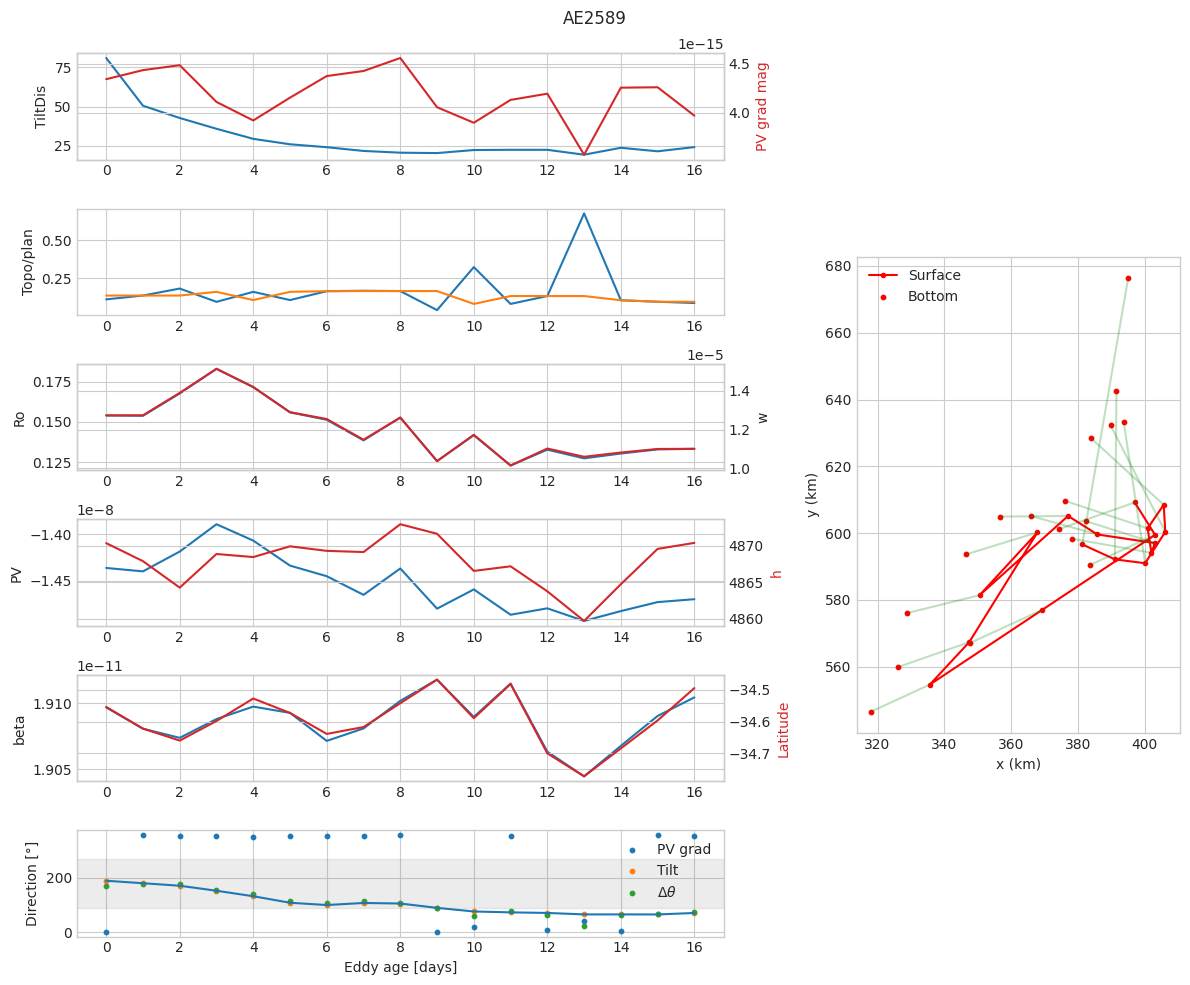

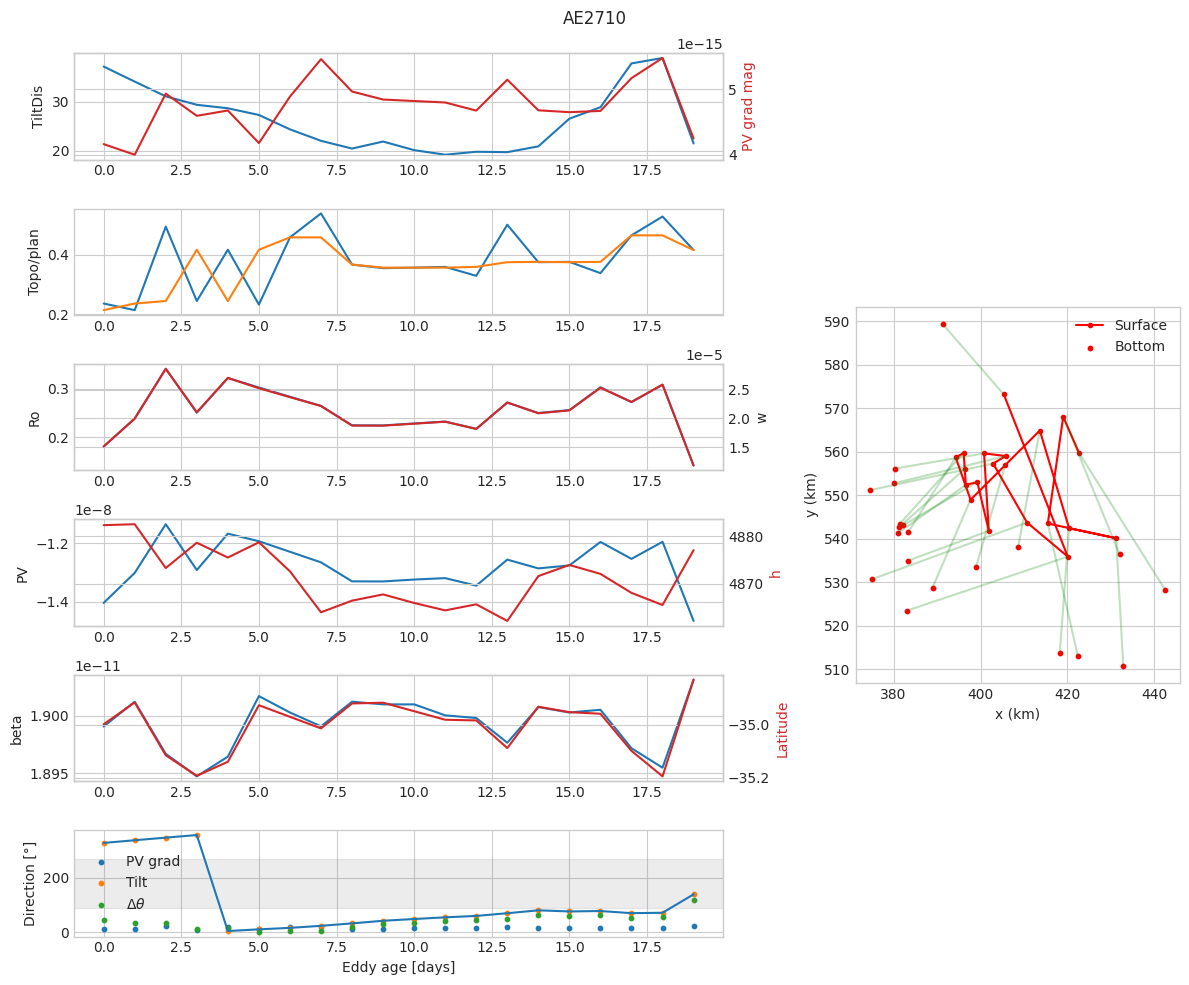

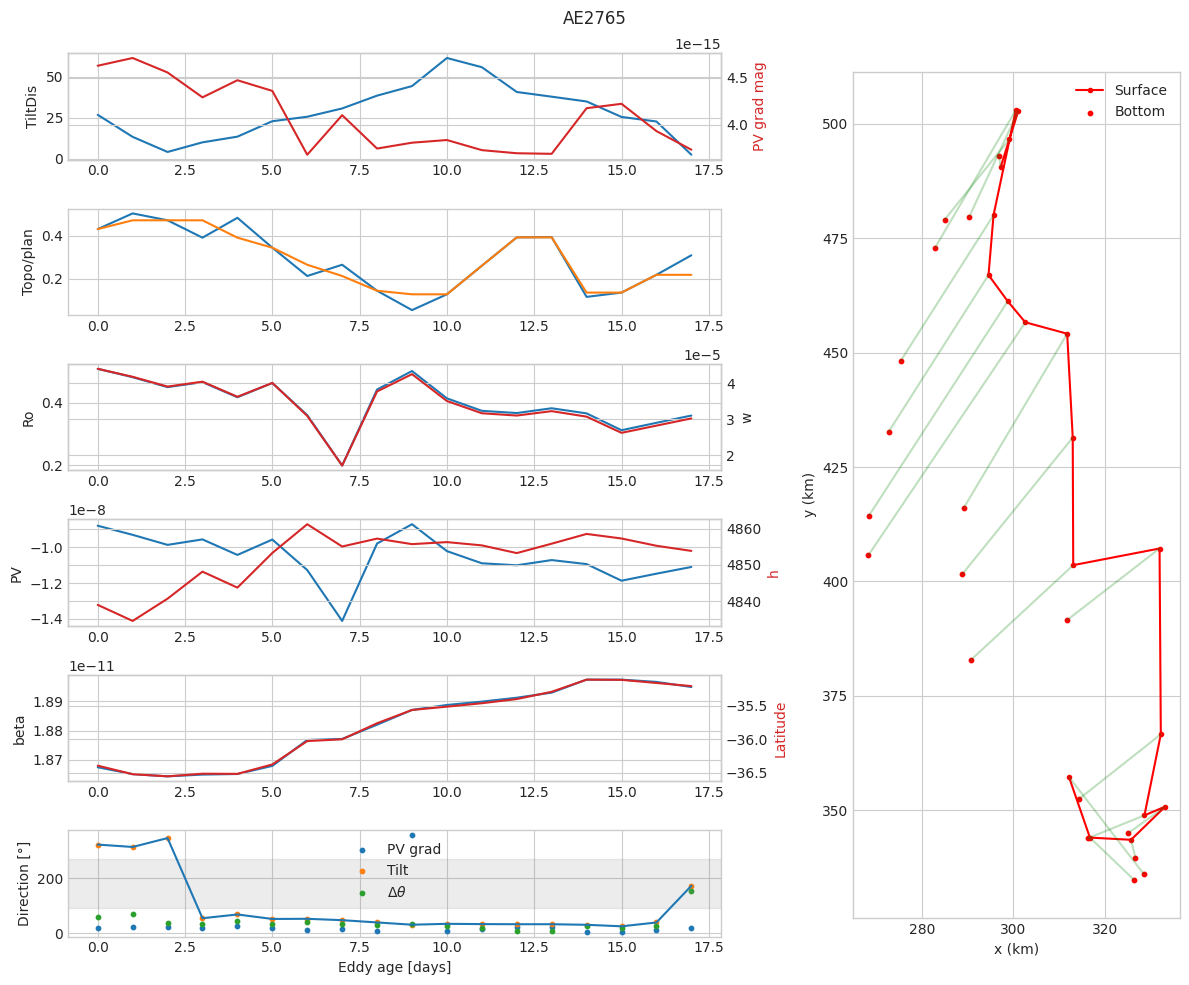

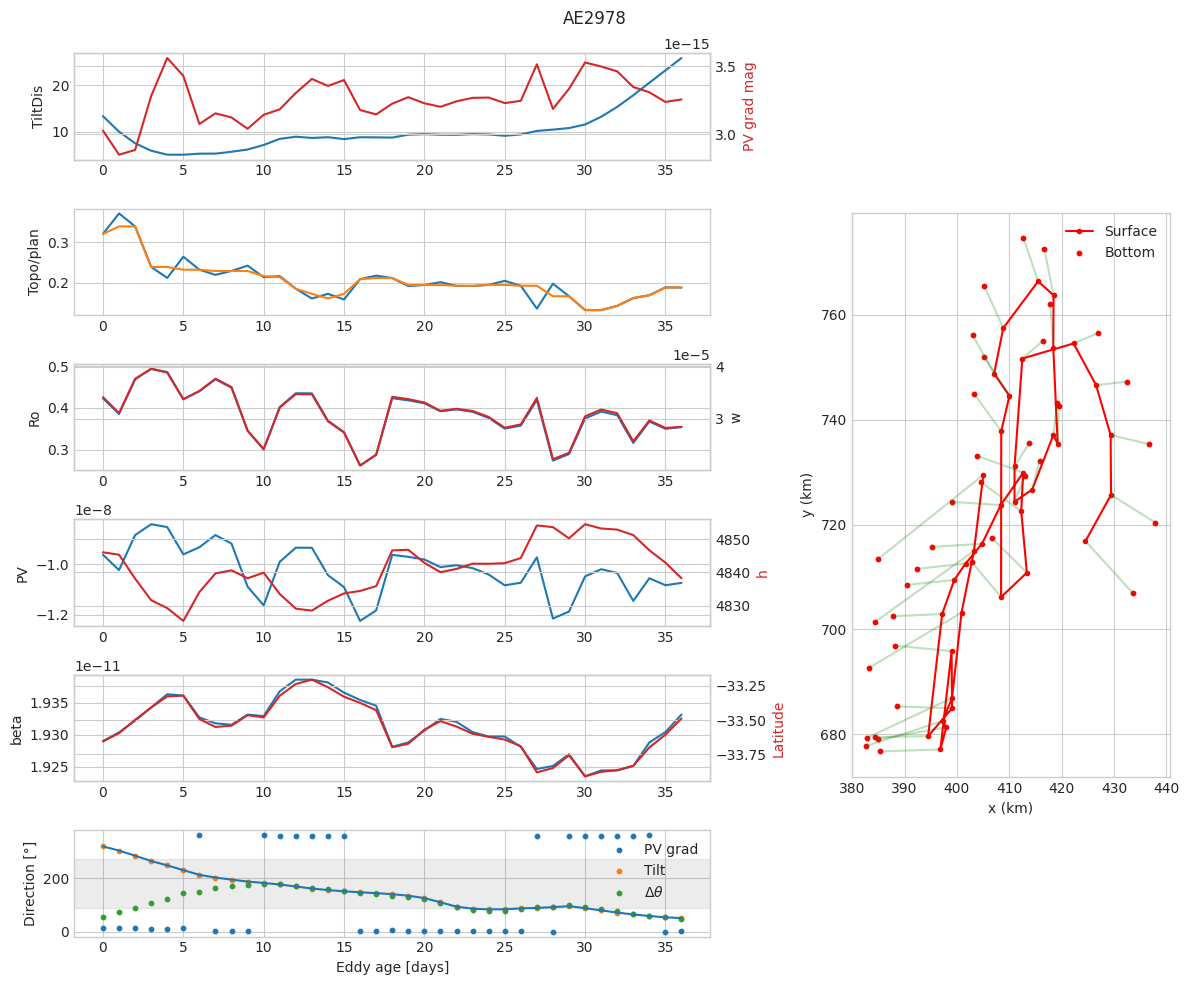

In [22]:
for eddy in df_complete.Eddy.unique():
    time_plot(eddy, df_complete)

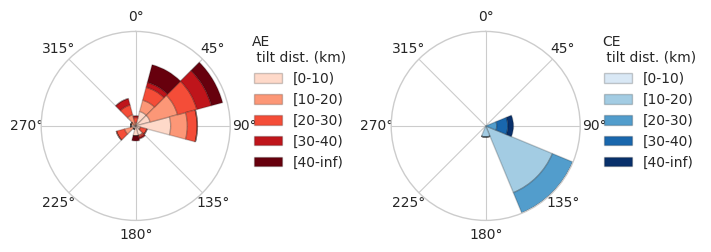

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(7, 4), subplot_kw={"projection": "polar"}, constrained_layout=True)
mag_bins = [0, 10, 20, 30, 40, np.inf]
for ax, cyc, colors in zip(axs, ["AE", "CE"], [plt.cm.Reds(np.linspace(0.15, 1, len(mag_bins) - 1)), plt.cm.Blues(np.linspace(0.15, 1, len(mag_bins) - 1))]):
    subset = df_complete.loc[df_complete.Cyc == cyc].dropna(subset=["TiltDir", "TiltDis"])
    tilt.plot_windrose(ax, subset, title='', mag_bins=mag_bins, colors=colors)
    ax.legend(title=f"{cyc}\n tilt dist. (km)", loc="upper left", bbox_to_anchor=(1.05, 1.05), frameon=False)
    ax.set_rticks([])
plt.show()